# Tobit Extension — Loss Given Default (LGD) Modelling
### Two-stage Credit Loss Framework: PD (Logit) × LGD (Tobit) × EAD

**Dataset:** UCI Default of Credit Card Clients (Taiwan, 2005)

---
#### Economic logic
Standard binary models only answer *"Will this client default?"* (PD).  
Credit risk management also requires *"If they default, how much do we lose?"* (LGD).  
LGD is a **censored** variable — observable only for defaulters, bounded in [0, 1].  
Tobit regression handles this censoring correctly via maximum likelihood.

#### Expected Loss formula
`EL = PD × LGD × EAD`  
where EAD (Exposure at Default) = credit limit (LIMIT_BAL).

---
#### Pipeline
1. Setup & data loading (from CSV)  
2. Feature engineering & LGD construction  
3. Exploratory analysis of LGD distribution  
4. Tobit Type I — standard censored regression (statsmodels)  
5. Tobit Type II — Heckman two-stage (separate selection & outcome equations)  
6. Marginal effects & coefficient interpretation  
7. LGD prediction diagnostics  
8. Expected Loss computation & portfolio analysis  
9. Model comparison & validation


## 1. Setup & Libraries

In [ ]:
# Install if needed (run once)
# !pip install statsmodels scikit-learn pandas numpy matplotlib seaborn


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
from statsmodels.base.model import GenericLikelihoodModel
from scipy import stats
from scipy.stats import norm
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})
C = {'pd': '#2563EB', 'lgd': '#DC2626', 'el': '#16A34A',
     'neutral': '#6B7280', 'light': '#E5E7EB'}


## 2. Data Loading & LGD Construction

### Constructing LGD from the dataset

The UCI dataset does not provide a direct loss amount, so we construct a  
**proxy LGD** that is standard practice in retail credit research:

```
LGD_proxy = Total payments made in 6 months / Bill outstanding at default
```

This approximates recovery rate — what fraction of the owed amount was paid back.  
`LGD = 1 − Recovery Rate`, clipped to [0, 1].

> In a real bank dataset, LGD would be the actual write-off amount / exposure.


In [2]:
df = pd.read_csv('UCI_Credit_Card.csv')
df.drop(columns=['ID'], inplace=True)
df.rename(columns={'default.payment.next.month': 'DEFAULT'}, inplace=True)

# ── Fix undocumented codes ────────────────────────────────────────────────────
df['EDUCATION'] = df['EDUCATION'].replace([0, 5, 6], 4)
df['MARRIAGE']  = df['MARRIAGE'].replace(0, 3)

print(f"Shape: {df.shape}")
print(f"Default rate: {df['DEFAULT'].mean():.3%}  ({df['DEFAULT'].sum():,} defaults)")


Shape: (30000, 24)
Default rate: 22.120%  (6,636 defaults)


In [3]:
# ── Feature engineering (mirrors ML notebook) ────────────────────────────────
bill_cols  = ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']
pay_cols   = ['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']
repay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']

df['AVG_BILL']    = df[bill_cols].mean(axis=1)
df['AVG_PAY_AMT'] = df[pay_cols].mean(axis=1)
df['UTIL_RATIO']  = (df['AVG_BILL'] / df['LIMIT_BAL'].replace(0, np.nan)).clip(upper=1).fillna(0)
df['MAX_DELAY']   = df[repay_cols].max(axis=1)
df['N_DELAY']     = (df[repay_cols] > 0).sum(axis=1)

total_bill = df[bill_cols].sum(axis=1).replace(0, np.nan)
df['PAY_BILL_RATIO'] = (df[pay_cols].sum(axis=1) / total_bill).clip(upper=5).fillna(0)

# ── Construct proxy LGD ───────────────────────────────────────────────────────
# Total amount owed = last bill statement (most recent)
# Total recovered   = sum of 6 months of payments
total_paid     = df[pay_cols].sum(axis=1)
total_exposure = df['BILL_AMT1'].replace(0, np.nan)   # most recent bill

# Recovery rate: how much of the bill was paid back
recovery_rate  = (total_paid / total_exposure).clip(lower=0, upper=1).fillna(0)

# LGD = 1 - recovery rate (bounded [0,1])
df['LGD_proxy'] = (1 - recovery_rate).clip(lower=0, upper=1)

# LGD is only meaningful for defaulters; for non-defaulters it's latent (censored)
# We keep the full column and use a censoring indicator
df['CENSORED'] = (df['DEFAULT'] == 0).astype(int)   # 1 = censored (did not default)

print("LGD for defaulters only:")
print(df.loc[df['DEFAULT']==1, 'LGD_proxy'].describe().round(4))
print(f"\nCensored observations (non-defaulters): {df['CENSORED'].sum():,}")
print(f"Uncensored observations (defaulters):    {(1-df['CENSORED']).sum():,}")


LGD for defaulters only:
count    6636.0000
mean        0.5642
std         0.3588
min         0.0000
25%         0.1828
50%         0.7081
75%         0.8201
max         1.0000
Name: LGD_proxy, dtype: float64

Censored observations (non-defaulters): 23,364
Uncensored observations (defaulters):    6,636


## 3. LGD Distribution Analysis

Before modelling, we examine the LGD distribution among defaulters.  
Key features to watch for: boundary mass at 0 and 1, skewness, bimodality.


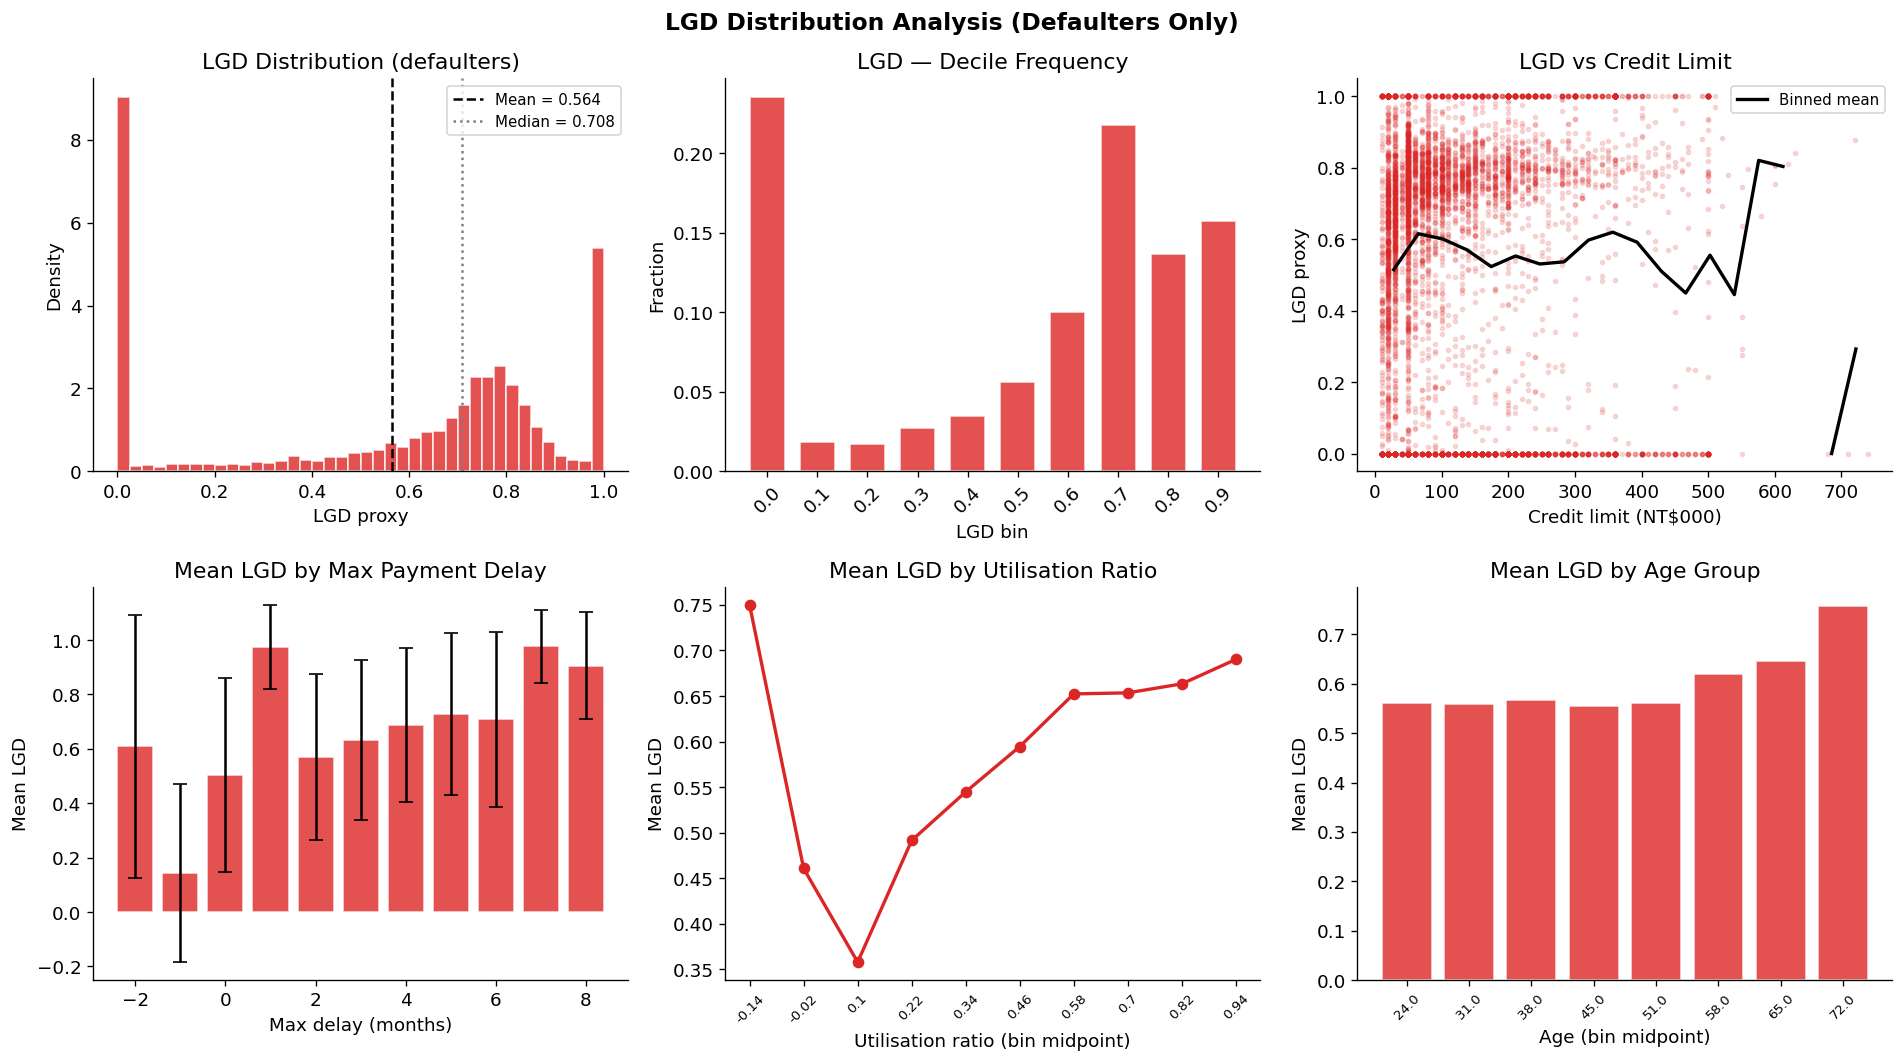

In [4]:
defaulters = df[df['DEFAULT'] == 1].copy()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('LGD Distribution Analysis (Defaulters Only)', fontsize=14, fontweight='bold')

# ── 3a: Raw LGD histogram ─────────────────────────────────────────────────────
ax = axes[0, 0]
ax.hist(defaulters['LGD_proxy'], bins=40, color=C['lgd'], alpha=0.8,
        edgecolor='white', density=True)
ax.axvline(defaulters['LGD_proxy'].mean(), color='k', linestyle='--', lw=1.5,
           label=f"Mean = {defaulters['LGD_proxy'].mean():.3f}")
ax.axvline(defaulters['LGD_proxy'].median(), color='gray', linestyle=':', lw=1.5,
           label=f"Median = {defaulters['LGD_proxy'].median():.3f}")
ax.set_title('LGD Distribution (defaulters)')
ax.set_xlabel('LGD proxy')
ax.set_ylabel('Density')
ax.legend(fontsize=9)

# ── 3b: Boundary mass check ───────────────────────────────────────────────────
ax = axes[0, 1]
bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
cnts, edges = np.histogram(defaulters['LGD_proxy'], bins=bins)
ax.bar([f"{b:.1f}" for b in bins[:-1]], cnts / cnts.sum(),
       color=C['lgd'], alpha=0.8, edgecolor='white', width=0.7)
ax.set_title('LGD — Decile Frequency')
ax.set_xlabel('LGD bin')
ax.set_ylabel('Fraction')
ax.tick_params(axis='x', rotation=45)

# ── 3c: LGD vs credit limit ───────────────────────────────────────────────────
ax = axes[0, 2]
ax.scatter(defaulters['LIMIT_BAL']/1000, defaulters['LGD_proxy'],
           alpha=0.15, s=6, color=C['lgd'])
# Binned mean
bins_lim = pd.cut(defaulters['LIMIT_BAL'], bins=20)
mean_lgd = defaulters.groupby(bins_lim)['LGD_proxy'].mean()
midpoints = [interval.mid / 1000 for interval in mean_lgd.index]
ax.plot(midpoints, mean_lgd.values, color='k', lw=2, label='Binned mean')
ax.set_title('LGD vs Credit Limit')
ax.set_xlabel('Credit limit (NT$000)')
ax.set_ylabel('LGD proxy')
ax.legend(fontsize=9)

# ── 3d: LGD vs MAX_DELAY ─────────────────────────────────────────────────────
ax = axes[1, 0]
delay_lgd = defaulters.groupby('MAX_DELAY')['LGD_proxy'].agg(['mean', 'std', 'count'])
ax.bar(delay_lgd.index, delay_lgd['mean'], color=C['lgd'], alpha=0.8,
       edgecolor='white', yerr=delay_lgd['std'], capsize=4)
ax.set_title('Mean LGD by Max Payment Delay')
ax.set_xlabel('Max delay (months)')
ax.set_ylabel('Mean LGD')

# ── 3e: LGD vs utilisation ratio ─────────────────────────────────────────────
ax = axes[1, 1]
util_bins = pd.cut(defaulters['UTIL_RATIO'], bins=10)
util_lgd  = defaulters.groupby(util_bins)['LGD_proxy'].mean()
ax.plot(range(len(util_lgd)), util_lgd.values, marker='o', color=C['lgd'], lw=2)
ax.set_xticks(range(len(util_lgd)))
ax.set_xticklabels([str(i.mid.round(2)) for i in util_lgd.index], rotation=45, fontsize=8)
ax.set_title('Mean LGD by Utilisation Ratio')
ax.set_xlabel('Utilisation ratio (bin midpoint)')
ax.set_ylabel('Mean LGD')

# ── 3f: LGD vs Age ───────────────────────────────────────────────────────────
ax = axes[1, 2]
age_bins = pd.cut(defaulters['AGE'], bins=8)
age_lgd  = defaulters.groupby(age_bins)['LGD_proxy'].agg(['mean', 'count'])
ax.bar(range(len(age_lgd)), age_lgd['mean'], color=C['lgd'], alpha=0.8,
       edgecolor='white')
ax.set_xticks(range(len(age_lgd)))
ax.set_xticklabels([str(i.mid.round(0)) for i in age_lgd.index], rotation=45, fontsize=8)
ax.set_title('Mean LGD by Age Group')
ax.set_xlabel('Age (bin midpoint)')
ax.set_ylabel('Mean LGD')

plt.tight_layout()
plt.savefig('lgd_eda.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Tobit Type I — Censored Regression

### Model specification

The Tobit Type I model assumes a single latent variable y* drives both  
selection (default or not) and the observed severity (LGD):

```
y*_i = X_i β + ε_i,    ε_i ~ N(0, σ²)

         y*_i   if y*_i > 0  (defaulter — uncensored)
y_i  =
         0      if y*_i ≤ 0  (non-defaulter — censored at zero)
```

The log-likelihood combines a probit term for censored observations  
and a normal density term for uncensored ones:

```
ln L = Σ_{censored}   ln Φ(−X_i β / σ)
      + Σ_{uncensored} ln φ((y_i − X_i β) / σ) − ln σ
```

statsmodels does not have a built-in Tobit, so we implement it via  
`GenericLikelihoodModel` — which is the standard approach.


In [5]:
class Tobit(GenericLikelihoodModel):
    """
    Tobit Type I — left-censored at zero.
    Observations with CENSORED==1 contribute the CDF term;
    uncensored observations contribute the PDF term.
    
    Parameters in self.exog: X matrix (with constant).
    endog: y vector (LGD values; 0 for censored obs is fine — they use the CDF branch).
    data.censored: boolean array, True if observation is censored (did not default).
    """

    def __init__(self, endog, exog, censored, **kwds):
        super().__init__(endog, exog, **kwds)
        self.censored = np.asarray(censored, dtype=bool)

    def nloglikeobs(self, params):
        beta = params[:-1]        # all except last parameter
        sigma = np.exp(params[-1])  # log-sigma parameterisation → always positive

        xb = self.exog @ beta
        y  = self.endog

        # Censored obs: y* ≤ 0, contribute Φ(-Xβ/σ)
        ll_censored = norm.logcdf(-xb[self.censored] / sigma)

        # Uncensored obs: contribute φ((y - Xβ)/σ) / σ
        resid = (y[~self.censored] - xb[~self.censored]) / sigma
        ll_uncensored = norm.logpdf(resid) - np.log(sigma)

        nll = np.empty(len(y))
        nll[self.censored]  = -ll_censored
        nll[~self.censored] = -ll_uncensored
        return nll

    def fit(self, start_params=None, method='bfgs', maxiter=500, **kwds):
        if start_params is None:
            # Initialise beta from OLS on uncensored, log-sigma from residual std
            ols = OLS(self.endog[~self.censored],
                      self.exog[~self.censored]).fit()
            start_params = np.append(ols.params, np.log(ols.resid.std()))
        return super().fit(start_params=start_params, method=method,
                           maxiter=maxiter, **kwds)

print("Tobit class defined.")


Tobit class defined.


In [6]:
# ── Prepare design matrix ─────────────────────────────────────────────────────
tobit_features = [
    'LIMIT_BAL', 'AGE', 'UTIL_RATIO', 'MAX_DELAY', 'N_DELAY',
    'PAY_BILL_RATIO', 'AVG_BILL', 'AVG_PAY_AMT'
]

# Standardise for numerical stability
scaler_t = StandardScaler()
X_t = pd.DataFrame(
    scaler_t.fit_transform(df[tobit_features]),
    columns=tobit_features
)
X_t = sm.add_constant(X_t)
y_t = df['LGD_proxy'].values
censored = df['CENSORED'].values.astype(bool)

print(f"Design matrix shape: {X_t.shape}")
print(f"Uncensored (defaulters): {(~censored).sum():,}  |  Censored: {censored.sum():,}")


Design matrix shape: (30000, 9)
Uncensored (defaulters): 6,636  |  Censored: 23,364


In [7]:
# ── Fit Tobit ─────────────────────────────────────────────────────────────────
tobit = Tobit(y_t, X_t.values, censored=censored)
tobit_result = tobit.fit(disp=False)
print(tobit_result.summary(xname=X_t.columns.tolist() + ['log_sigma']))


                                Tobit Results                                 
Dep. Variable:                      y   Log-Likelihood:                -15773.
Model:                          Tobit   AIC:                         3.157e+04
Method:            Maximum Likelihood   BIC:                         3.165e+04
Date:                Fri, 10 Apr 2026                                         
Time:                        22:31:16                                         
No. Observations:               30000                                         
Df Residuals:                   29991                                         
Df Model:                           8                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.6408      0.011    -59.774      0.000      -0.662      -0.620
LIMIT_BAL         -0.0269      0.010    

### Interpreting Tobit coefficients

Unlike OLS, the Tobit coefficients are **latent-index effects** — the effect of X on  
the unobserved y*. To get the effect on the *observed* LGD (conditional on defaulting),  
we apply the **McDonald–Moffit decomposition**:

```
∂E[y|y>0] / ∂x_k  =  β_k × Φ(z)           (intensive margin — severity conditional on default)
∂P(y>0) / ∂x_k    =  β_k × φ(z) / σ        (extensive margin — probability of being uncensored)
```

where z = Xβ/σ and Φ, φ are the standard normal CDF and PDF.


In [8]:
def tobit_marginal_effects(result, X, censored, feature_names):
    """
    McDonald-Moffit decomposition of Tobit marginal effects.
    Returns DataFrame with intensive-margin and extensive-margin MEs.
    """
    params = result.params
    beta   = params[:-1]
    sigma  = np.exp(params[-1])

    xb = X @ beta
    z  = xb / sigma

    phi_z = norm.pdf(z)
    Phi_z = norm.cdf(z)

    # Use only uncensored obs for average z
    z_unc  = z[~censored]
    phi_m  = norm.pdf(z_unc).mean()
    Phi_m  = norm.cdf(z_unc).mean()

    rows = []
    for i, name in enumerate(feature_names):
        b = beta[i]
        me_intensive  = b * Phi_m                  # effect on E[y | y>0]
        me_extensive  = b * phi_m / sigma           # effect on P(y>0)
        me_total      = me_intensive + z_unc.mean() * me_extensive  # total unconditional
        rows.append({
            'Variable':       name,
            'Coefficient':    round(b, 5),
            'ME (intensive)': round(me_intensive, 5),
            'ME (extensive)': round(me_extensive, 5),
            'ME (total)':     round(me_total, 5)
        })

    return pd.DataFrame(rows)

me_df = tobit_marginal_effects(
    tobit_result,
    X_t.values,
    censored,
    X_t.columns.tolist()
)
print(me_df.to_string(index=False))


      Variable  Coefficient  ME (intensive)  ME (extensive)  ME (total)
         const     -0.64080        -0.22383        -0.25871    -0.10783
     LIMIT_BAL     -0.02690        -0.00940        -0.01086    -0.00453
           AGE      0.03361         0.01174         0.01357     0.00566
    UTIL_RATIO      0.02463         0.00860         0.00994     0.00414
     MAX_DELAY      0.10371         0.03623         0.04187     0.01745
       N_DELAY      0.24350         0.08505         0.09831     0.04097
PAY_BILL_RATIO     -0.00575        -0.00201        -0.00232    -0.00097
      AVG_BILL      0.05164         0.01804         0.02085     0.00869
   AVG_PAY_AMT     -0.19387        -0.06772        -0.07827    -0.03262


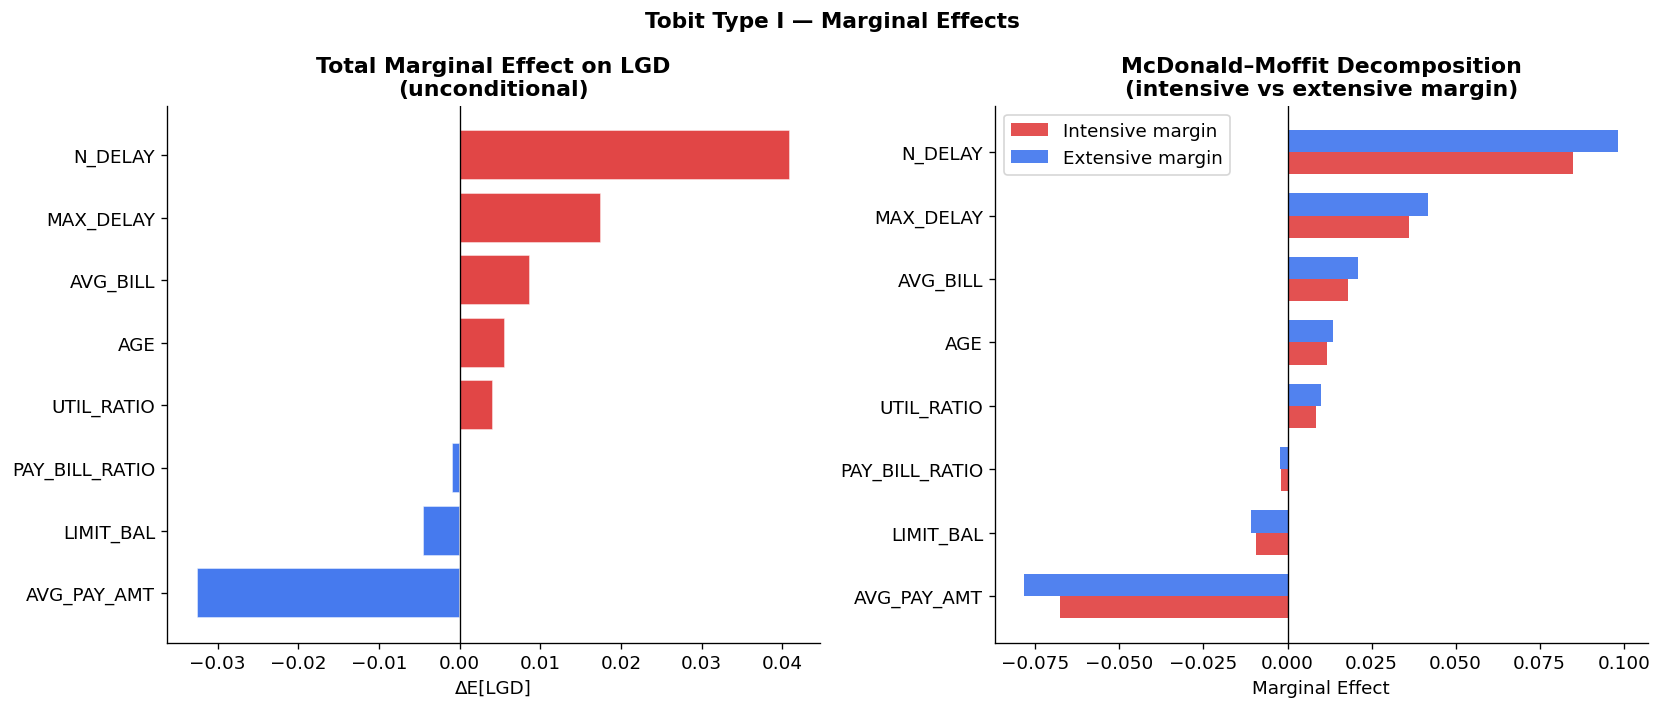

In [9]:
# ── Marginal Effects Plot ─────────────────────────────────────────────────────
me_plot = me_df[me_df['Variable'] != 'const'].sort_values('ME (total)')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: total marginal effect
colors = [C['lgd'] if v > 0 else C['pd'] for v in me_plot['ME (total)']]
axes[0].barh(me_plot['Variable'], me_plot['ME (total)'],
             color=colors, alpha=0.85, edgecolor='white')
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title('Total Marginal Effect on LGD\n(unconditional)', fontweight='bold')
axes[0].set_xlabel('ΔE[LGD]')

# Right: intensive vs extensive decomposition
x_pos = np.arange(len(me_plot))
w = 0.35
axes[1].barh(x_pos - w/2, me_plot['ME (intensive)'].values,
             height=w, label='Intensive margin', color=C['lgd'], alpha=0.8)
axes[1].barh(x_pos + w/2, me_plot['ME (extensive)'].values,
             height=w, label='Extensive margin', color=C['pd'], alpha=0.8)
axes[1].set_yticks(x_pos)
axes[1].set_yticklabels(me_plot['Variable'].values)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].legend()
axes[1].set_title('McDonald–Moffit Decomposition\n(intensive vs extensive margin)',
                  fontweight='bold')
axes[1].set_xlabel('Marginal Effect')

plt.suptitle('Tobit Type I — Marginal Effects', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('tobit_me.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Tobit Type II — Heckman Two-Stage Selection Model

### Why Type II?

Tobit Type I assumes the **same latent process** drives both whether default occurs  
and how severe it is. This is restrictive: in practice the drivers of *deciding to default*  
(e.g., payment behaviour, delay history) may differ from the drivers of *loss severity*  
(e.g., credit limit, utilisation).

**Heckman two-stage** separates the two equations:

```
Selection equation:  DEFAULT_i = 1[Z_i γ + u_i > 0],    u_i ~ N(0,1)   ← Probit
Outcome equation:    LGD_i = W_i β + ε_i,  observed only if DEFAULT_i=1  ← OLS with correction

Correction term: λ_i = φ(Z_i γ̂) / Φ(Z_i γ̂)   (Inverse Mills Ratio)
```

Adding λ (the Inverse Mills Ratio) to the outcome equation corrects for the  
selection bias that would arise if you ran OLS only on defaulters.

**Identification:** For the model to be identified, the selection equation should  
contain at least one variable excluded from the outcome equation (an **exclusion restriction**).  
Here we use `N_DELAY` and `MAX_DELAY` as instruments — they strongly predict default  
but are less directly linked to the severity of loss.


In [10]:
# ── Stage 1: Probit selection equation ───────────────────────────────────────
# Selection features: all predictors + instruments
selection_features = [
    'LIMIT_BAL', 'AGE', 'UTIL_RATIO', 'MAX_DELAY', 'N_DELAY',
    'PAY_BILL_RATIO', 'AVG_BILL', 'AVG_PAY_AMT'
]

scaler_h = StandardScaler()
X_sel = pd.DataFrame(
    scaler_h.fit_transform(df[selection_features]),
    columns=selection_features
)
X_sel_const = sm.add_constant(X_sel)

probit_sel = sm.Probit(df['DEFAULT'], X_sel_const).fit(disp=False)
print("Selection equation (Probit):")
print(probit_sel.summary())


Selection equation (Probit):
                          Probit Regression Results                           
Dep. Variable:                DEFAULT   No. Observations:                30000
Model:                         Probit   Df Residuals:                    29991
Method:                           MLE   Df Model:                            8
Date:                Fri, 10 Apr 2026   Pseudo R-squ.:                  0.1406
Time:                        22:31:44   Log-Likelihood:                -13623.
converged:                       True   LL-Null:                       -15853.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.8534      0.009    -96.335      0.000      -0.871      -0.836
LIMIT_BAL         -0.0876      0.014     -6.364      0.000      -0.115      -0.061
AGE    

In [11]:
# ── Compute Inverse Mills Ratio (IMR) ────────────────────────────────────────
# IMR = φ(Zγ̂) / Φ(Zγ̂) — evaluated at all observations
xg = X_sel_const.values @ probit_sel.params.values
imr = norm.pdf(xg) / norm.cdf(xg)

df['IMR'] = imr
print(f"IMR summary (all obs):")
print(pd.Series(imr).describe().round(4))


IMR summary (all obs):
count    30000.0000
mean         1.4311
std          0.3866
min          0.1826
25%          1.2465
50%          1.5536
75%          1.6558
max          9.5170
dtype: float64


In [12]:
# ── Stage 2: OLS outcome equation on defaulters only ─────────────────────────
# Outcome features: excludes the instruments (N_DELAY, MAX_DELAY)
outcome_features = [
    'LIMIT_BAL', 'AGE', 'UTIL_RATIO',
    'PAY_BILL_RATIO', 'AVG_BILL', 'AVG_PAY_AMT'
]

defaulters_idx = df['DEFAULT'] == 1

X_out = pd.DataFrame(
    scaler_h.fit_transform(df.loc[defaulters_idx, outcome_features]),
    columns=outcome_features
)
X_out['IMR'] = df.loc[defaulters_idx, 'IMR'].values   # add correction term
X_out = sm.add_constant(X_out)

y_out = df.loc[defaulters_idx, 'LGD_proxy'].values

heckman_result = OLS(y_out, X_out).fit(cov_type='HC3')  # robust SE
print("Outcome equation (Heckman Stage 2 — OLS with IMR):")
print(heckman_result.summary())


Outcome equation (Heckman Stage 2 — OLS with IMR):
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.242
Model:                            OLS   Adj. R-squared:                  0.241
Method:                 Least Squares   F-statistic:                     205.1
Date:                Fri, 10 Apr 2026   Prob (F-statistic):          1.69e-276
Time:                        22:32:03   Log-Likelihood:                -1693.4
No. Observations:                6636   AIC:                             3403.
Df Residuals:                    6628   BIC:                             3457.
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------

### Interpreting the Heckman results

The **IMR coefficient** (λ) tests for selection bias:
- If the IMR coefficient is statistically significant → selection bias is present  
  and Heckman correction is necessary.
- If it is not significant → simple OLS on defaulters is unbiased (no selection problem).

The other coefficients in the outcome equation are direct **OLS estimates of ∂LGD/∂x**,  
interpreted as the change in loss severity for defaulters, holding other factors constant.


## 6. LGD Prediction & Diagnostic Plots

In [13]:
# ── Tobit Type I: E[y | X, uncensored] ───────────────────────────────────────
params_t = tobit_result.params
beta_t   = params_t[:-1]
sigma_t  = np.exp(params_t[-1])

xb_t = X_t.values @ beta_t
z_t  = xb_t / sigma_t

# Conditional expectation: E[y | y>0, X] = Xβ + σ · φ(z)/Φ(z)  (truncated normal)
mills_t = norm.pdf(z_t) / np.where(norm.cdf(z_t) > 1e-10, norm.cdf(z_t), 1e-10)
lgd_pred_tobit = np.clip(xb_t + sigma_t * mills_t, 0, 1)
df['LGD_pred_tobit'] = lgd_pred_tobit

# ── Heckman: predicted LGD for defaulters ────────────────────────────────────
X_all_out = pd.DataFrame(
    scaler_h.transform(df[outcome_features]),
    columns=outcome_features
)
X_all_out['IMR'] = df['IMR'].values
X_all_out = sm.add_constant(X_all_out)

lgd_pred_heckman = np.clip(heckman_result.predict(X_all_out), 0, 1)
df['LGD_pred_heckman'] = lgd_pred_heckman

print("LGD predictions computed for all observations.")
print("\nPredicted LGD summary (defaulters):")
print(df.loc[df['DEFAULT']==1, ['LGD_pred_tobit','LGD_pred_heckman','LGD_proxy']].describe().round(4))


LGD predictions computed for all observations.

Predicted LGD summary (defaulters):
       LGD_pred_tobit  LGD_pred_heckman  LGD_proxy
count       6636.0000         6636.0000  6636.0000
mean           0.5285            0.5666     0.5642
std            0.1487            0.1571     0.3588
min            0.1912            0.0000     0.0000
25%            0.4110            0.4663     0.1828
50%            0.4839            0.5708     0.7081
75%            0.6142            0.6676     0.8201
max            1.0000            1.0000     1.0000


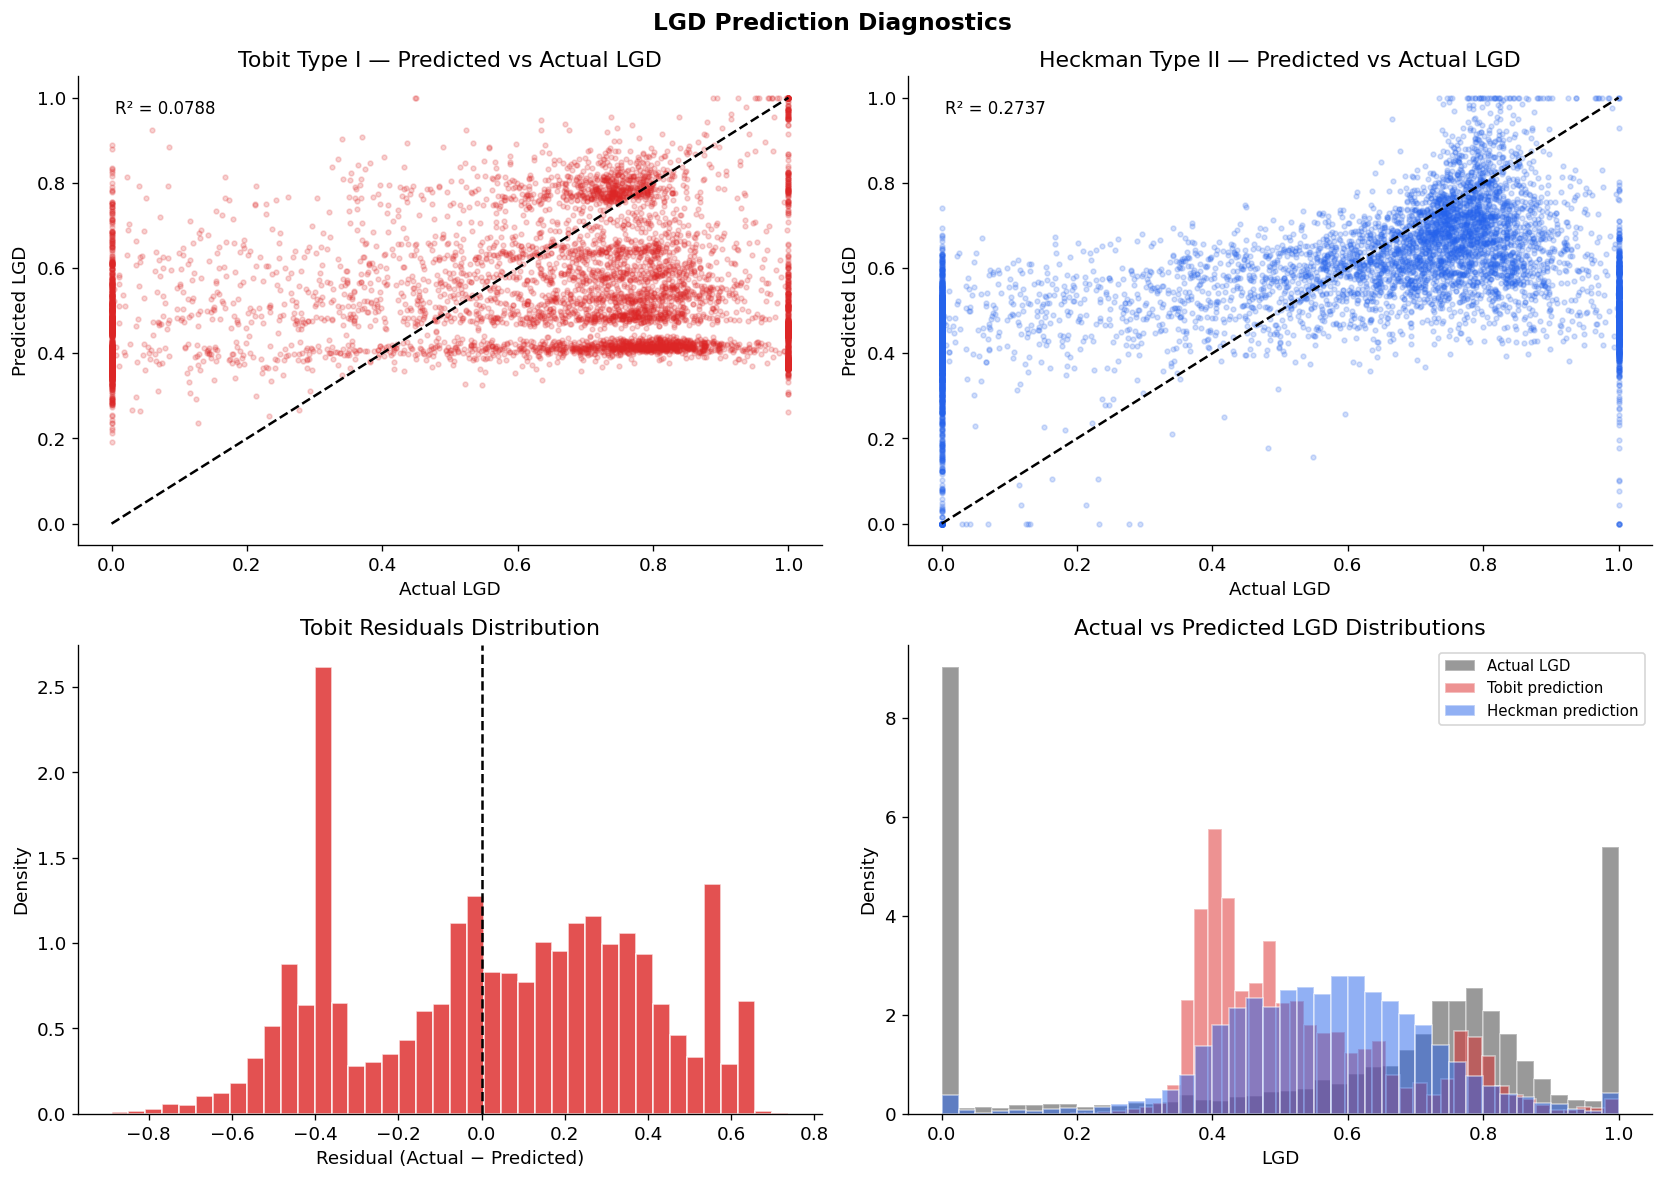

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('LGD Prediction Diagnostics', fontsize=14, fontweight='bold')

defaulters_mask = df['DEFAULT'] == 1

# ── Tobit: predicted vs actual ────────────────────────────────────────────────
ax = axes[0, 0]
ax.scatter(df.loc[defaulters_mask, 'LGD_proxy'],
           df.loc[defaulters_mask, 'LGD_pred_tobit'],
           alpha=0.2, s=8, color=C['lgd'])
ax.plot([0, 1], [0, 1], 'k--', lw=1.5)
ax.set_title('Tobit Type I — Predicted vs Actual LGD')
ax.set_xlabel('Actual LGD')
ax.set_ylabel('Predicted LGD')
r2 = np.corrcoef(df.loc[defaulters_mask, 'LGD_proxy'],
                 df.loc[defaulters_mask, 'LGD_pred_tobit'])[0,1]**2
ax.text(0.05, 0.92, f'R² = {r2:.4f}', transform=ax.transAxes, fontsize=10)

# ── Heckman: predicted vs actual ─────────────────────────────────────────────
ax = axes[0, 1]
ax.scatter(df.loc[defaulters_mask, 'LGD_proxy'],
           df.loc[defaulters_mask, 'LGD_pred_heckman'],
           alpha=0.2, s=8, color=C['pd'])
ax.plot([0, 1], [0, 1], 'k--', lw=1.5)
ax.set_title('Heckman Type II — Predicted vs Actual LGD')
ax.set_xlabel('Actual LGD')
ax.set_ylabel('Predicted LGD')
r2h = np.corrcoef(df.loc[defaulters_mask, 'LGD_proxy'],
                  df.loc[defaulters_mask, 'LGD_pred_heckman'])[0,1]**2
ax.text(0.05, 0.92, f'R² = {r2h:.4f}', transform=ax.transAxes, fontsize=10)

# ── Residuals: Tobit ──────────────────────────────────────────────────────────
ax = axes[1, 0]
resid_t = df.loc[defaulters_mask, 'LGD_proxy'] - df.loc[defaulters_mask, 'LGD_pred_tobit']
ax.hist(resid_t, bins=40, color=C['lgd'], alpha=0.8, edgecolor='white', density=True)
ax.axvline(0, color='k', lw=1.5, linestyle='--')
ax.set_title('Tobit Residuals Distribution')
ax.set_xlabel('Residual (Actual − Predicted)')
ax.set_ylabel('Density')

# ── Model comparison: distribution overlay ───────────────────────────────────
ax = axes[1, 1]
def_actual = df.loc[defaulters_mask, 'LGD_proxy']
ax.hist(def_actual,
        bins=40, alpha=0.4, density=True, color='black',
        label='Actual LGD', edgecolor='white')
ax.hist(df.loc[defaulters_mask, 'LGD_pred_tobit'],
        bins=40, alpha=0.5, density=True, color=C['lgd'],
        label='Tobit prediction', edgecolor='white')
ax.hist(df.loc[defaulters_mask, 'LGD_pred_heckman'],
        bins=40, alpha=0.5, density=True, color=C['pd'],
        label='Heckman prediction', edgecolor='white')
ax.set_title('Actual vs Predicted LGD Distributions')
ax.set_xlabel('LGD')
ax.set_ylabel('Density')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('lgd_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. PD Model — Logit (brief refit for EL computation)

We refit a Logistic Regression on the full dataset to obtain PD estimates  
for every client. This connects directly to your earlier ML notebook.


In [15]:
pd_features = [
    'LIMIT_BAL', 'AGE', 'UTIL_RATIO', 'MAX_DELAY', 'N_DELAY',
    'PAY_BILL_RATIO', 'AVG_BILL', 'AVG_PAY_AMT'
]
df_dummy = pd.get_dummies(df, columns=['SEX', 'EDUCATION', 'MARRIAGE'], drop_first=True)

all_features = [c for c in df_dummy.columns
                if c not in ['DEFAULT','LGD_proxy','CENSORED','IMR',
                             'LGD_pred_tobit','LGD_pred_heckman'] + bill_cols + pay_cols]

X_pd = df_dummy[all_features].astype(float)
y_pd = df_dummy['DEFAULT']

scaler_pd = StandardScaler()
X_pd_sc   = scaler_pd.fit_transform(X_pd)

lr_pd = LogisticRegression(C=0.1, max_iter=1000, random_state=42)
lr_pd.fit(X_pd_sc, y_pd)

df['PD_logit'] = lr_pd.predict_proba(X_pd_sc)[:, 1]
auc_pd = roc_auc_score(y_pd, df['PD_logit'])
print(f"Logit PD model fitted. AUC on full data: {auc_pd:.4f}")
print(f"Mean predicted PD: {df['PD_logit'].mean():.4f}  (actual default rate: {y_pd.mean():.4f})")


Logit PD model fitted. AUC on full data: 0.7572
Mean predicted PD: 0.2212  (actual default rate: 0.2212)


## 8. Expected Loss = PD × LGD × EAD

**EAD (Exposure at Default)** = credit limit (LIMIT_BAL)  
We compute EL using both Tobit and Heckman LGD estimates.


In [16]:
df['EAD'] = df['LIMIT_BAL']

# Expected Loss with Tobit LGD
df['EL_tobit']   = df['PD_logit'] * df['LGD_pred_tobit']   * df['EAD']

# Expected Loss with Heckman LGD
df['EL_heckman'] = df['PD_logit'] * df['LGD_pred_heckman'] * df['EAD']

print("=== Portfolio Expected Loss Summary ===")
print(f"Total portfolio EAD:              NT$ {df['EAD'].sum():>15,.0f}")
print(f"Total EL (Tobit LGD):             NT$ {df['EL_tobit'].sum():>15,.0f}")
print(f"Total EL (Heckman LGD):           NT$ {df['EL_heckman'].sum():>15,.0f}")
print(f"EL / EAD ratio (Tobit):           {df['EL_tobit'].sum()/df['EAD'].sum():.4f}")
print(f"EL / EAD ratio (Heckman):         {df['EL_heckman'].sum()/df['EAD'].sum():.4f}")
print(f"\nPer-client EL (Tobit):")
print(df['EL_tobit'].describe().apply(lambda x: f'NT$ {x:,.0f}').to_string())


=== Portfolio Expected Loss Summary ===
Total portfolio EAD:              NT$   5,024,529,680
Total EL (Tobit LGD):             NT$     421,547,673
Total EL (Heckman LGD):           NT$     488,426,284
EL / EAD ratio (Tobit):           0.0839
EL / EAD ratio (Heckman):         0.0972

Per-client EL (Tobit):
count     NT$ 30,000
mean      NT$ 14,052
std       NT$ 19,044
min            NT$ 0
25%        NT$ 4,717
50%        NT$ 8,664
75%       NT$ 14,485
max      NT$ 445,384


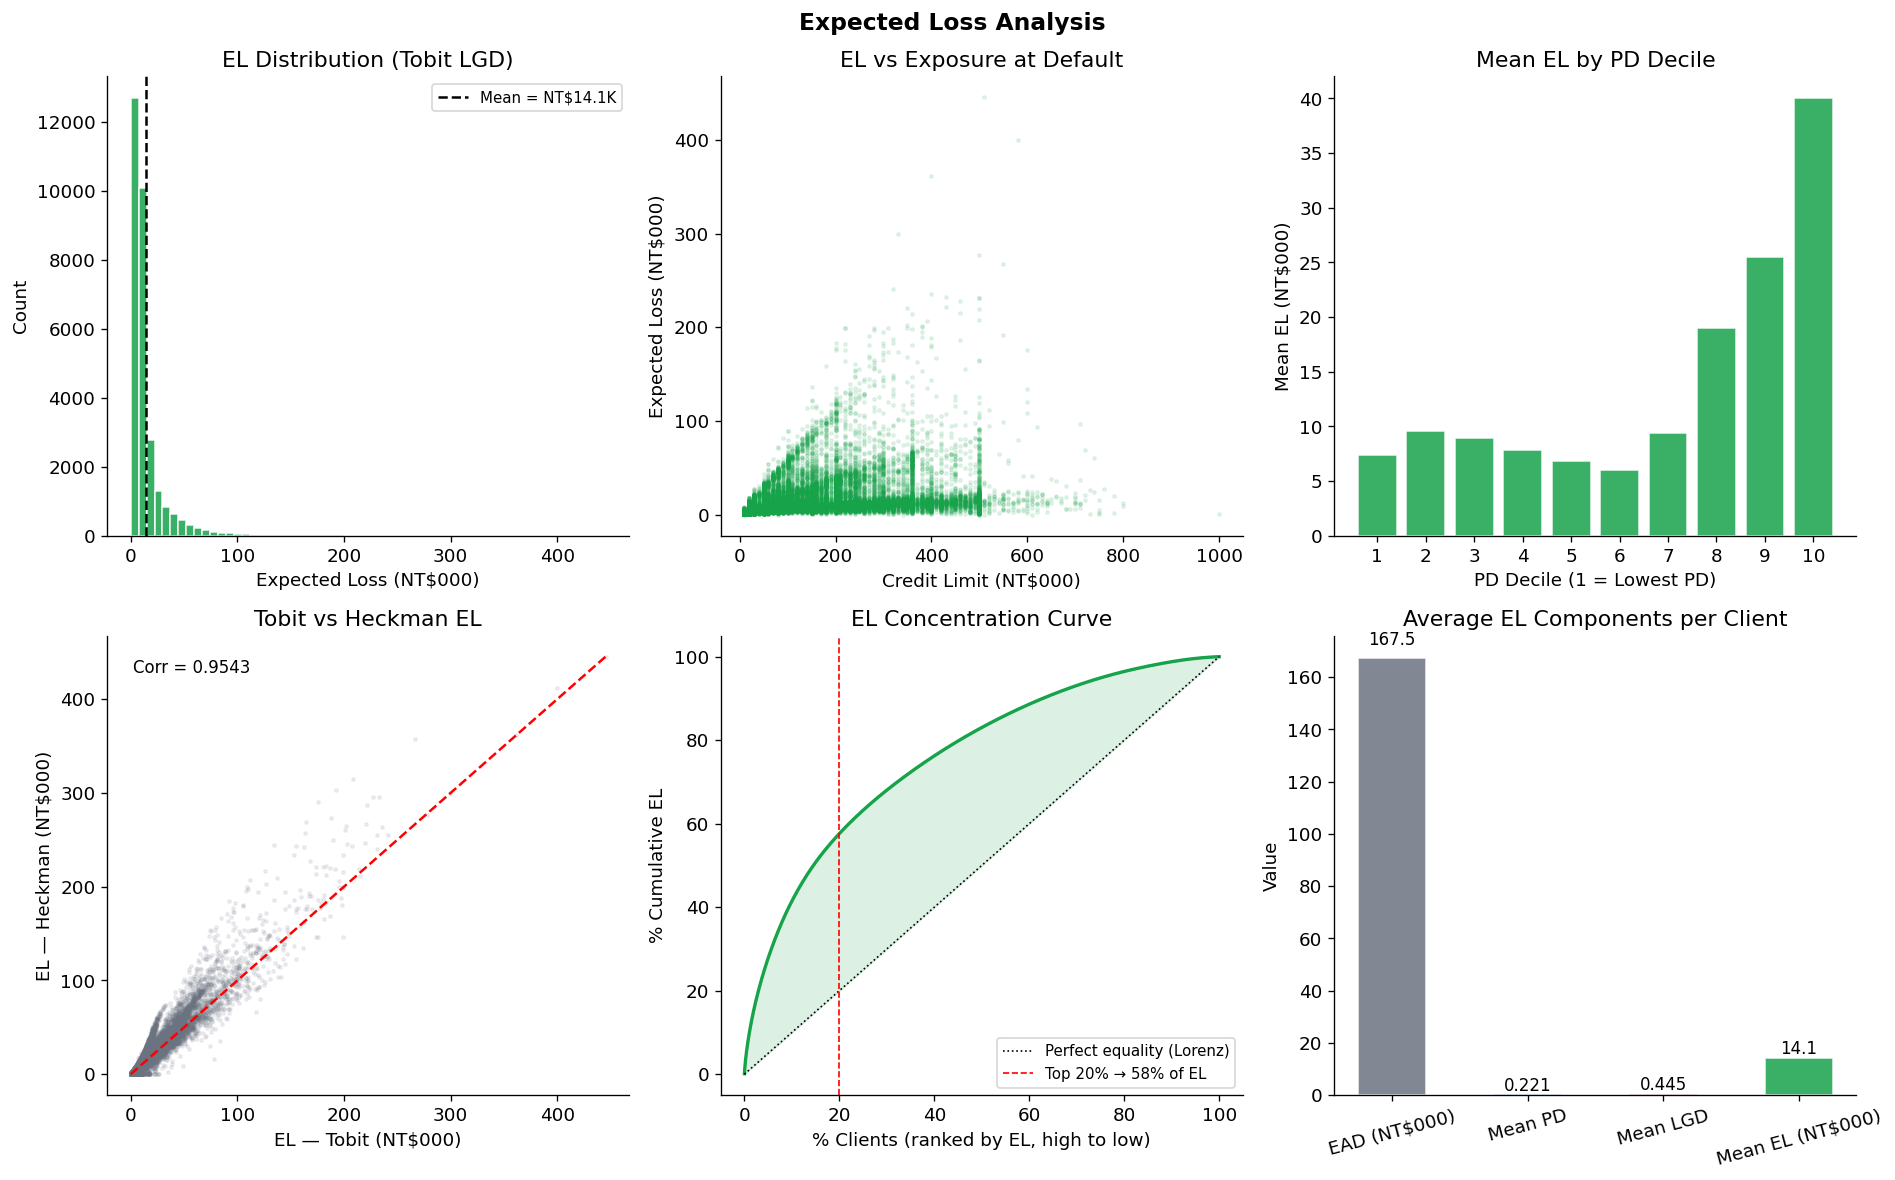

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Expected Loss Analysis', fontsize=14, fontweight='bold')

# ── 8a: EL distribution (Tobit) ──────────────────────────────────────────────
ax = axes[0, 0]
ax.hist(df['EL_tobit']/1000, bins=60, color=C['el'], alpha=0.85, edgecolor='white')
ax.axvline(df['EL_tobit'].mean()/1000, color='k', linestyle='--',
           lw=1.5, label=f"Mean = NT${df['EL_tobit'].mean()/1000:.1f}K")
ax.set_title('EL Distribution (Tobit LGD)')
ax.set_xlabel('Expected Loss (NT$000)')
ax.set_ylabel('Count')
ax.legend(fontsize=9)

# ── 8b: EL vs Credit Limit ───────────────────────────────────────────────────
ax = axes[0, 1]
ax.scatter(df['EAD']/1000, df['EL_tobit']/1000,
           alpha=0.1, s=4, color=C['el'])
ax.set_title('EL vs Exposure at Default')
ax.set_xlabel('Credit Limit (NT$000)')
ax.set_ylabel('Expected Loss (NT$000)')

# ── 8c: EL by decile of PD ───────────────────────────────────────────────────
ax = axes[0, 2]
df['PD_decile'] = pd.qcut(df['PD_logit'], q=10, labels=False)
pd_el = df.groupby('PD_decile').agg(
    mean_pd=('PD_logit', 'mean'),
    mean_el=('EL_tobit', 'mean')
).reset_index()
ax.bar(pd_el['PD_decile']+1, pd_el['mean_el']/1000,
       color=C['el'], alpha=0.85, edgecolor='white')
ax.set_title('Mean EL by PD Decile')
ax.set_xlabel('PD Decile (1 = Lowest PD)')
ax.set_ylabel('Mean EL (NT$000)')
ax.set_xticks(range(1, 11))

# ── 8d: Tobit vs Heckman EL scatter ─────────────────────────────────────────
ax = axes[1, 0]
ax.scatter(df['EL_tobit']/1000, df['EL_heckman']/1000,
           alpha=0.1, s=4, color=C['neutral'])
ax.plot([0, df[['EL_tobit','EL_heckman']].max().max()/1000],
        [0, df[['EL_tobit','EL_heckman']].max().max()/1000],
        'r--', lw=1.5)
ax.set_title('Tobit vs Heckman EL')
ax.set_xlabel('EL — Tobit (NT$000)')
ax.set_ylabel('EL — Heckman (NT$000)')
corr_el = df[['EL_tobit','EL_heckman']].corr().iloc[0,1]
ax.text(0.05, 0.92, f'Corr = {corr_el:.4f}', transform=ax.transAxes, fontsize=10)

# ── 8e: Concentration — top 20% of EL ────────────────────────────────────────
ax = axes[1, 1]
df_sorted = df.sort_values('EL_tobit', ascending=False)
cum_el = np.cumsum(df_sorted['EL_tobit'].values) / df['EL_tobit'].sum() * 100
cum_pop = np.arange(1, len(df)+1) / len(df) * 100
ax.plot(cum_pop, cum_el, color=C['el'], lw=2)
ax.plot([0,100],[0,100],'k:', lw=1, label='Perfect equality (Lorenz)')
ax.fill_between(cum_pop, cum_el, cum_pop, alpha=0.15, color=C['el'])
ax.set_title('EL Concentration Curve')
ax.set_xlabel('% Clients (ranked by EL, high to low)')
ax.set_ylabel('% Cumulative EL')
top20_share = np.interp(20, cum_pop, cum_el)
ax.axvline(20, color='red', linestyle='--', lw=1,
           label=f'Top 20% → {top20_share:.0f}% of EL')
ax.legend(fontsize=9)

# ── 8f: EL components breakdown (avg per client) ─────────────────────────────
ax = axes[1, 2]
avg_ead = df['EAD'].mean()
avg_pd  = df['PD_logit'].mean()
avg_lgd = df['LGD_pred_tobit'].mean()
components = ['EAD (NT$000)', 'Mean PD', 'Mean LGD', 'Mean EL (NT$000)']
values = [avg_ead/1000, avg_pd, avg_lgd, df['EL_tobit'].mean()/1000]
colors_bar = [C['neutral'], C['pd'], C['lgd'], C['el']]
bars = ax.bar(components, values, color=colors_bar, alpha=0.85, edgecolor='white', width=0.5)
for bar, val, comp in zip(bars, values, components):
    fmt = f'{val:.3f}' if 'PD' in comp or 'LGD' in comp else f'{val:.1f}'
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
            fmt, ha='center', va='bottom', fontsize=10)
ax.set_title('Average EL Components per Client')
ax.set_ylabel('Value')
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('expected_loss.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Model Comparison & Validation

In [18]:
# ── Compare on defaulters (where actual LGD is observed) ────────────────────
def_mask = df['DEFAULT'] == 1

actual  = df.loc[def_mask, 'LGD_proxy'].values
pred_t  = df.loc[def_mask, 'LGD_pred_tobit'].values
pred_h  = df.loc[def_mask, 'LGD_pred_heckman'].values

# Naive benchmarks
pred_ols_mean = np.full(def_mask.sum(), actual.mean())   # predict mean LGD
ols_default   = OLS(actual, sm.add_constant(
    pd.DataFrame(scaler_t.transform(df.loc[def_mask, tobit_features]),
                 columns=tobit_features)
)).fit()
pred_ols_reg  = ols_default.fittedvalues

def rmse(y, yhat): return np.sqrt(np.mean((y - yhat)**2))
def mae(y, yhat):  return np.mean(np.abs(y - yhat))
def r2(y, yhat):   return 1 - np.sum((y-yhat)**2)/np.sum((y-y.mean())**2)

comparison = pd.DataFrame({
    'Model':  ['Tobit Type I', 'Heckman Type II',
               'OLS (defaulters only)', 'Naive mean'],
    'RMSE':   [rmse(actual,pred_t), rmse(actual,pred_h),
               rmse(actual,pred_ols_reg), rmse(actual,pred_ols_mean)],
    'MAE':    [mae(actual,pred_t),  mae(actual,pred_h),
               mae(actual,pred_ols_reg),  mae(actual,pred_ols_mean)],
    'R²':     [r2(actual,pred_t),   r2(actual,pred_h),
               r2(actual,pred_ols_reg),   r2(actual,pred_ols_mean)]
})
comparison = comparison.set_index('Model').round(5)
print(comparison.to_string())


                          RMSE      MAE       R²
Model                                           
Tobit Type I           0.34952  0.29895  0.05102
Heckman Type II        0.30730  0.24299  0.26641
OLS (defaulters only)  0.31191  0.24621  0.24423
Naive mean             0.35879  0.31085  0.00000


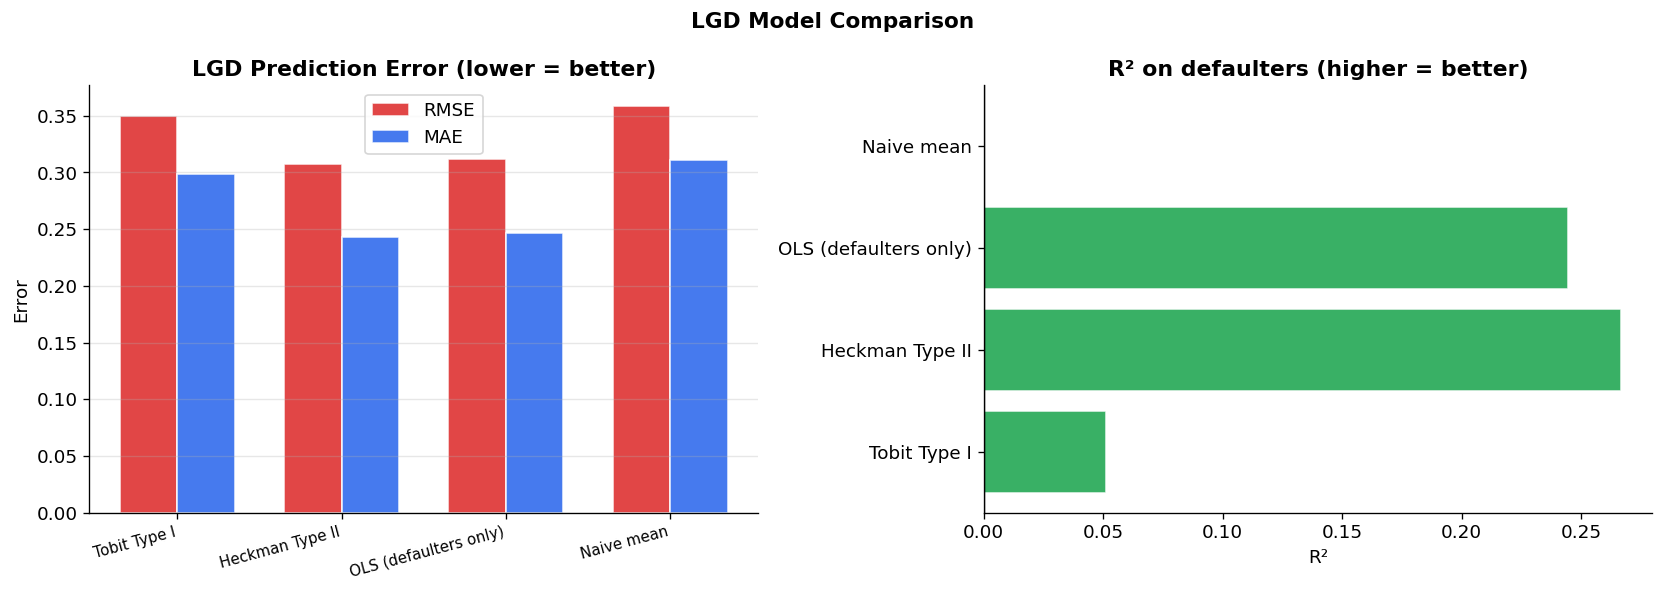


Key takeaway: if Tobit/Heckman R² > OLS R², the censoring correction is adding value.
If they are similar, the selection bias in this dataset is mild.
The Heckman IMR coefficient significance tells you definitively.


In [19]:
# ── Visual comparison ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: RMSE / MAE grouped bar
x = np.arange(len(comparison))
w = 0.35
axes[0].bar(x - w/2, comparison['RMSE'], width=w, label='RMSE',
            color=C['lgd'], alpha=0.85, edgecolor='white')
axes[0].bar(x + w/2, comparison['MAE'],  width=w, label='MAE',
            color=C['pd'], alpha=0.85, edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison.index, rotation=15, ha='right', fontsize=9)
axes[0].set_title('LGD Prediction Error (lower = better)', fontweight='bold')
axes[0].set_ylabel('Error')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Right: R²
axes[1].barh(comparison.index, comparison['R²'],
             color=C['el'], alpha=0.85, edgecolor='white')
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('R² on defaulters (higher = better)', fontweight='bold')
axes[1].set_xlabel('R²')

plt.suptitle('LGD Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lgd_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey takeaway: if Tobit/Heckman R² > OLS R², the censoring correction is adding value.")
print("If they are similar, the selection bias in this dataset is mild.")
print("The Heckman IMR coefficient significance tells you definitively.")


## Summary & Interpretation Guide

| Concept | What it means in practice |
|---|---|
| **Tobit coefficient** | Effect of X on the latent loss propensity (not directly interpretable as ΔE[LGD]) |
| **Intensive margin ME** | How much average LGD changes among those who already default |
| **Extensive margin ME** | How much the probability of defaulting (and thus having any LGD) changes |
| **IMR significance** | If significant → selection bias is real; Heckman correction is necessary |
| **EL = PD × LGD × EAD** | Full credit risk pricing formula; all three components needed for regulatory capital |

### Limitations of the proxy LGD
- The proxy used here (1 − payments/bill) is a **research approximation**. A real bank uses  
  the actual write-off amount divided by the outstanding balance at the time of default.
- True LGD also depends on collateral, recovery costs, and the time value of money  
  (discounted recoveries). These are not in this dataset.
- For regulatory purposes (Basel III), LGD must be estimated over a full economic cycle,  
  not just a 6-month window.
